<a href="https://colab.research.google.com/github/pcmouadji-dot/deep_learning/blob/main/Bank_Turnover2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [192]:
import numpy as np
import sklearn as skl
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import classification_report


In [193]:
df=pd.read_csv("/content/Churn_Modelling.csv")

# DE

In [194]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [195]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [197]:
df.shape

(10000, 14)

# treating the data


In [198]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True,dtype=int)
df["broke"]=(df["Balance"]==0).astype(int)
df["balance/EstimatedSalary"]=df["Balance"]/df["EstimatedSalary"]
df["EstimatedSalary/CreditScore"]=df["EstimatedSalary"]/df["CreditScore"]
scaler=StandardScaler()
train_x,test_x,train_y,test_y=train_test_split(df.drop(columns=["Exited"]),df["Exited"],test_size=0.2,random_state=18)
train_x=scaler.fit_transform(train_x)
test_x=scaler.transform(test_x)

In [199]:
display(pd.DataFrame(train_x))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-0.004539,-0.463337,-0.351426,0.477627,-0.913761,-1.556190,0.961491,0.752024,-0.576773,-0.568882,0.914169,-0.758567,-0.114333,0.660504
1,-1.712664,0.012393,-1.044404,-0.013232,-0.913761,0.642595,0.961491,-0.506199,-0.576773,-0.568882,-1.093890,-0.758567,-0.093333,-0.120544
2,0.958222,-0.368191,0.341551,0.051574,-0.913761,0.642595,0.961491,1.628157,-0.576773,1.757834,0.914169,-0.758567,-0.135715,1.083668
3,-0.687789,-0.748775,-0.004937,-1.219167,0.814800,0.642595,-1.040051,-1.187946,-0.576773,-0.568882,0.914169,1.318276,-0.162259,-1.085738
4,1.983096,-0.177899,-0.351426,0.900851,0.814800,0.642595,-1.040051,-0.220807,-0.576773,-0.568882,-1.093890,-0.758567,-0.063919,-0.565166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0.078279,1.058999,-1.044404,-1.219167,0.814800,0.642595,-1.040051,-0.828494,-0.576773,1.757834,0.914169,1.318276,-0.162259,-0.819306
7996,-1.464210,-0.653629,1.381018,1.512552,-0.913761,0.642595,0.961491,-1.358911,1.733785,-0.568882,0.914169,-0.758567,0.347446,-1.205247
7997,1.299847,-0.082753,-0.004937,0.578087,-0.913761,-1.556190,0.961491,-0.171710,1.733785,-0.568882,0.914169,-0.758567,-0.081508,-0.434461
7998,0.098983,0.297831,-0.004937,-1.219167,0.814800,0.642595,-1.040051,0.273894,-0.576773,1.757834,0.914169,1.318276,-0.162259,0.187634


# building the model

In [200]:
model=keras.Sequential([
    keras.layers.Dense(64,activation="relu",input_shape=(train_x.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16,activation="relu"),
    keras.layers.Dense(1,activation="sigmoid")
])

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
model.fit(train_x,train_y,epochs=50,class_weight={0:1,1:1.5})



Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7818 - loss: 0.6002
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8075 - loss: 0.5404
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8211 - loss: 0.5048
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8354 - loss: 0.4824
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8424 - loss: 0.4680
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8462 - loss: 0.4607
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8429 - loss: 0.4550
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8503 - loss: 0.4499
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8515 - loss: 0.4499
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8474 - loss: 0.4518
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8534 - loss: 0.4425
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy

# Evaluation

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


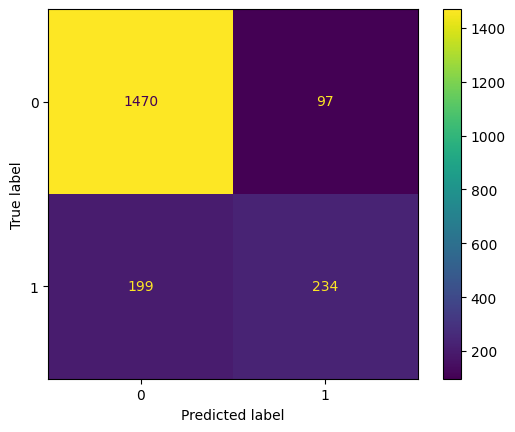

In [201]:
prediction=model.predict(test_x)
prediction=prediction.round().astype(int)
cm=confusion_matrix(test_y,prediction)
cmd=ConfusionMatrixDisplay(cm)
cmd.plot()

In [202]:
print(classification_report(test_y,prediction))
# i tried changing the weights but when i improve recall precision get worst<---->

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1567
           1       0.71      0.54      0.61       433

    accuracy                           0.85      2000
   macro avg       0.79      0.74      0.76      2000
weighted avg       0.84      0.85      0.84      2000

